In [113]:
##### IMPORTS

import os, re
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
##### BASIC CONFIGURATIONS

cloud_dict = {'Fe': '1', 'H2O': '2', 'KCl': '3', 'Mg2SiO4': '4',
              'MgSiO3': '5', 'MnS': '6', 'NH3': '7', 'Na2S': '8'}

digit_to_species = {v: k for k, v in cloud_dict.items()}


In [108]:
##### CLOUD FREE CONFIGURATION

clfreedir  = r"C:\Users\Alex\Desktop\Picaso\NN_project\sample_out\\" # Peter data
clfreelis  = [f for f in os.listdir(clfreedir) if f.endswith(".npy")]

# Which case to load, WILL PROBABLY DO A LOOP TO INDEX SPECIFIC T AND G BUT LATER
i          = 13
clfreename = clfreelis[i]
print(f"Cloud free case: {clfreename}")

# Parse T (K) and g (m/s^2)
m = re.match(r"t(?P<T>[0-9.]+)g(?P<G>[0-9.]+)\.npy$", clfreename)
T = float(m.group("T"))
g = float(m.group("G"))

# Loading in the flux from file
clfreeFLUX = np.load(os.path.join(clfreedir, clfreename), allow_pickle=True)


# Creating wavenumber grid
wnmin, wnmax  = 333.3, 20000.0
wn            = np.linspace(wnmax, wnmin, clfreeFLUX.size)
# Convert to micron, should be 0.5 to 30 micron
wl            = 1e4 / wn
wlmin, wlmax  = np.min(wl), np.max(wl)
# Convert FLUX to per micron
clfreeFLM     = clfreeFLUX * (1e4 / wl**2)
# Sort
idx           = np.argsort(wl)
wl_val        = wl[idx]
fl_val        = clfreeFLM[idx]

Cloud free case: t1434.6237805136786g1810.9604362929638.npy


In [109]:
##### CLOUD CONFIGURATION

cloudydir  = r"C:\Users\Alex\Desktop\Picaso\NN_project\outputs\\"
cloudylis  = [f for f in os.listdir(cloudydir) if f.endswith(".npy")]

# Which case to load, WILL PROBABLY DO A LOOP TO INDEX SPECIFIC T AND G BUT LATER
i          = 9
cloudyname = cloudylis[i]
print(f"Cloudy case: {cloudyname}")

# Parse T (K) and logg (dex) and fsed and kzz
pat = r"t(?P<T>[0-9.]+)g(?P<logg>[0-9.]+)f(?P<fsed>[0-9.]+)k(?P<kzz>[\deE.+-]+)c(?P<codes>[0-9]+)\.npy$"
m = re.match(pat, cloudyname)
clT   = float(m.group("T"))
logg  = float(m.group("logg"))          # cgs, dex
fsed  = float(m.group("fsed"))
kzz   = m.group("kzz")                  # string like "1e10"
cloud_codes = list(m.group("codes"))    # e.g., ['1','3','4','5','6','8']
clouds_used = [digit_to_species.get(d, f"code{d}") for d in cloud_codes]
# Compute g in m/s^2 from log g (cgs)
clg   = (10.0**logg) * 1e-2

# Loading in the flux from file

cloudyFLUX = np.load(os.path.join(cloudydir, cloudyname), allow_pickle=True)

# Creating wavenumber grid - HALF OF PETER SO FAR, CHANGE WHEN RUNNING 30 MICRON
wnminc, wnmaxc  = 666.7, 20000.0
wnc             = np.linspace(wnmaxc, wnminc, cloudyFLUX.size)
# Convert to micron, should be 0.5 to 30 micron
wlc             = 1e4 / wnc
wlminc, wlmaxc  = np.min(wlc), np.max(wlc)
# Convert FLUX to per micron
cloudyFLM       = cloudyFLUX * (1e4 / wlc**2)
# Sort
idxc            = np.argsort(wlc)
wlc_val         = wlc[idxc]
flc_val         = cloudyFLM[idxc]

Cloudy case: t1434.6237805136786g5.257908962469035f8.0k1e10c14568.npy


In [110]:
print(clfreelis)

['t1044.8224577246915g122.15862366601215.npy', 't1063.5378582827498g2313.2794249250665.npy', 't1079.7992765365211g1556.1460105917254.npy', 't1136.1362308231248g2257.322610837038.npy', 't1166.3029108944627g2606.2463781501074.npy', 't1200.093076864605g1784.4520544112743.npy', 't1225.7058485591833g2064.053457341064.npy', 't1253.0270586044937g1082.0568603568015.npy', 't1270.292782305211g2465.789486699228.npy', 't1309.25680641979g3054.8145226424954.npy', 't1351.6243204380194g1060.001475631001.npy', 't1369.6818680668557g1858.6986211595147.npy', 't1402.5663104100565g419.2684631147308.npy', 't1434.6237805136786g1810.9604362929638.npy', 't1465.0196844016696g1477.5758142360305.npy', 't1489.725055781985g2604.3669252828668.npy', 't1521.7950928737425g1131.6692576149926.npy', 't1566.670706518689g1763.2034365075706.npy', 't1617.8997022651074g2082.957875911686.npy', 't1663.6703731812245g1152.7145082424565.npy', 't1694.1959447291918g2549.564891024087.npy', 't1736.980697611616g2970.846899101895.npy', 't

In [111]:
print(cloudylis)

['t1166.3029108944627g5.416015468787659f1.0k1e10c14568.npy', 't1166.3029108944627g5.416015468787659f2.0k1e10c14568.npy', 't1166.3029108944627g5.416015468787659f3.0k1e10c134568.npy', 't1166.3029108944627g5.416015468787659f4.0k1e10c134568.npy', 't1166.3029108944627g5.416015468787659f8.0k1e10c134568.npy', 't1434.6237805136786g5.257908962469035f1.0k1e10c1456.npy', 't1434.6237805136786g5.257908962469035f2.0k1e10c14568.npy', 't1434.6237805136786g5.257908962469035f3.0k1e10c14568.npy', 't1434.6237805136786g5.257908962469035f4.0k1e10c14568.npy', 't1434.6237805136786g5.257908962469035f8.0k1e10c14568.npy', 't920.3427714874017g4.30863214606469f1.0k1e10c134568.npy', 't920.3427714874017g4.30863214606469f2.0k1e10c134568.npy', 't920.3427714874017g4.30863214606469f3.0k1e10c134568.npy', 't920.3427714874017g4.30863214606469f4.0k1e10c134568.npy', 't920.3427714874017g4.30863214606469f8.0k1e10c134568.npy']


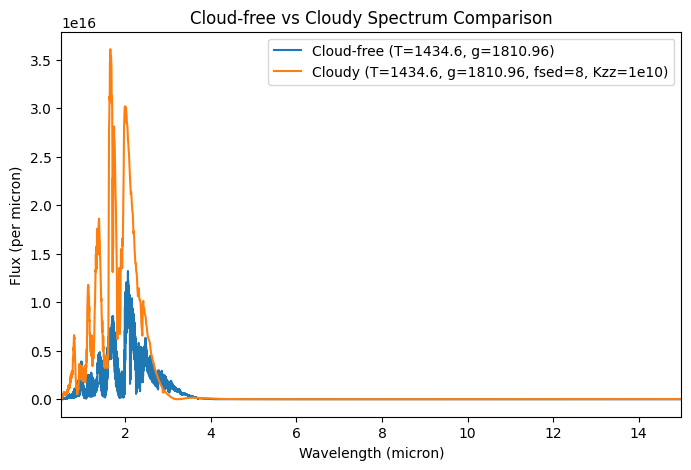

Cloud species used: Fe, Mg2SiO4, MgSiO3, MnS, Na2S


In [112]:
##### PLOT CASES

# CLOUD FREE

#plt.figure(figsize=(8,5))
#plt.plot(wl_val, fl_val)
#plt.xlabel("Wavelength (micron)")
#plt.ylabel("Flux (per micron)")
#plt.title(f"Cloud-free | T={T:.1f} K, g={g:.2f} m s$^{{-2}}$")
#plt.show()

# CLOUDY

# Print which clouds were used
#print("Cloud species used:", ", ".join(clouds_used))
#subtitle = (f"T={clT:.1f} K, g={clg:.2f} m s$^{{-2}}$, fsed={fsed:g}, "
#            f"Kzz={kzz}")
#plt.figure(figsize=(8,5))
#plt.plot(wlc_val, flc_val)
#plt.xlabel("Wavelength (micron)")
#plt.ylabel("Flux (per micron)")
#plt.title("Cloudy\n" + subtitle)
#plt.show()

# OVERLAY

plt.figure(figsize=(8,5))
plt.plot(wl_val, fl_val, label=f"Cloud-free (T={T:.1f}, g={g:.2f})")
plt.plot(wlc_val, flc_val, label=f"Cloudy (T={clT:.1f}, g={clg:.2f}, fsed={fsed:g}, Kzz={kzz})")
plt.xlabel("Wavelength (micron)")
plt.ylabel("Flux (per micron)")
plt.title("Cloud-free vs Cloudy Spectrum Comparison")
plt.legend()
plt.xlim(wlc_val.min(), wlc_val.max())
plt.show()
print("Cloud species used:", ", ".join(clouds_used))
